# 1. Einleitung

## Hintergrund & Motivation
Die Trinkgeld-Analyse ist in der Gastronomie und Hotellerie sehr beliebt, um herauszufinden, welche Faktoren (z. B. Höhe der Rechnung, Tageszeit, Personenanzahl) das Trinkgeld beeinflussen. Basierend auf diesen Informationen können Service-Kräfte und Managements ihre Angebote verbessern und das Personal besser schulen.

## Zielsetzung
Ziel ist, mithilfe des bekannten „Tips“-Datensatzes zu untersuchen, wie verschiedene Faktoren mit der Höhe des Trinkgelds zusammenhängen. Wir wollen zunächst den Datensatz validieren, uns die Verteilung des Trinkgelds anschauen, Gruppenvergleiche durchführen und einen Blick auf mögliche Zusammenhänge (Korrelationen, einfache Regression) werfen.

## Datenquelle
Der Datensatz „Tips“ ist Teil der Seaborn-Bibliothek und enthält Informationen über Restaurantbesuche (z. B. Gesamtrechnung, Trinkgeld, Geschlecht, Raucherstatus, Wochentag).

---

# 2. Methodik

## 2.1 Datenüberblick & erste Sichtung
Wir beginnen mit dem Laden und Validieren des Datensatzes. Das bedeutet, wir schauen uns die Struktur (`.info()`) an, prüfen auf fehlende Werte und machen uns mit den Variablen vertraut.

## 2.2 Datenbereinigung und Validierung
Wir prüfen, ob es fehlende Werte oder Ausreißer gibt. Falls nötig, würden wir sie entfernen oder anpassen. Der „Tips“-Datensatz ist allerdings recht gut aufbereitet, sodass in der Regel keine Bereinigung nötig ist.

## 2.3 Analytischer Ansatz
1. **Deskriptive Statistik**: Verteilung und Kennzahlen wie Mittelwert, Standardabweichung usw.
2. **Gruppenvergleiche**: Wie unterscheiden sich Trinkgelder z. B. zwischen Rauchern und Nichtrauchern, verschiedenen Wochentagen oder Geschlechtern?
3. **Multidimensionale Visualisierung**: Wie könnten wir möglichst viele Einfflussfaktoren visualisieren?
4. **Korrelationen**: Wie stark hängen einzelne Variablen zusammen? (z. B. `total_bill` und `tip`)

## 2.4 Werkzeuge
- **Python**: Hauptsprache der Analyse
- **pandas**: Datenverarbeitung
- **NumPy**: Numerische Basisfunktionen
- **Matplotlib** und **Seaborn**: Datenvisualisierung

---

In [2]:
# =============================================================
# Code-Zelle 1: Laden der Bibliotheken und des Datensatzes
# =============================================================
import pandas as pd
import numpy as np
import seaborn as sns   # zum Laden des Datensatzes & ggf. Vis-Stil
import matplotlib.pyplot as plt

# Optional: Seaborn-Theme aktivieren:
# sns.set_theme()

# Datensatz "tips" laden
df = sns.load_dataset("tips")

# Erster Blick auf die Daten
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# =============================================================
# Code-Zelle 2: Validierung: Struktur und fehlende Werte
# =============================================================
df.info()

# Prüfung auf fehlende Werte
print("\nAnzahl fehlender Werte pro Spalte:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Anzahl fehlender Werte pro Spalte:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


### Interpretation:
- `.info()` zeigt uns, aus wie vielen Zeilen und Spalten das DataFrame besteht und ob es Datentypen gibt, die unpassend sein könnten.
- In diesem Datensatz erwarten wir in der Regel keine fehlenden Werte; mit `.isnull().sum()` prüfen wir das dennoch.
- Im Regelfall wird ausgegeben, dass keine Werte fehlen.

---

# 3. Ergebnisse

## 3.1 Deskriptive Statistiken
Mit `df.describe()` erhalten wir einen statistischen Überblick über die numerischen Spalten:

In [30]:
# =============================================================
# Code-Zelle 3: Deskriptive Statistiken
# =============================================================
df_desc = df.describe(include='all')
df_desc

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


Hier sehen wir Werte wie **Mittelwert (mean)**, **Standardabweichung (std)**, **Minimum (min)**, **Maximum (max)** und verschiedene Perzentile.

Darüber hinaus lohnt sich ein Blick auf die **Verteilung** der wichtigsten Variablen – insbesondere `tip` und `total_bill`.

---

## 3.2 Visualisierungen

### 3.2.1 Verteilung des Trinkgelds
Mit Seaborn könntest du beispielsweise `sns.histplot(data=df, x="tip", bins=10, kde=True)` verwenden, um ein kombiniertes Histogramm mit Dichtekurve zu erhalten. Unten zeige ich dasselbe in Matplotlib.

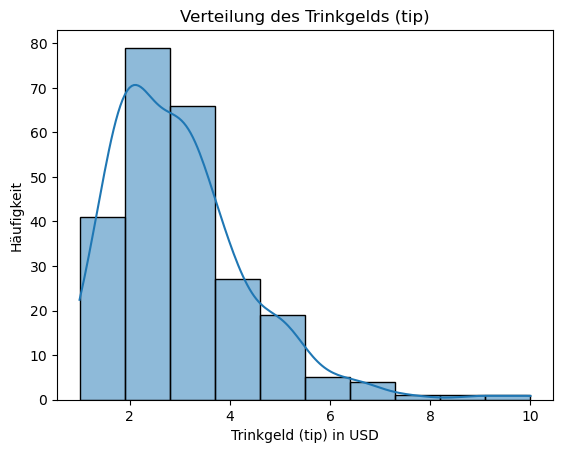

In [7]:
# =============================================================
# Code-Zelle 4: Verteilung Trinkgeld (tip)
# =============================================================
# plt.hist(df["tip"], bins=10)
# Alternativ mit Seaborn:
sns.histplot(data=df, x="tip", bins=10, kde=True)
plt.xlabel("Trinkgeld (tip) in USD")
plt.ylabel("Häufigkeit")
plt.title("Verteilung des Trinkgelds (tip)")
plt.show()

### Interpretation:
- Die Trinkgeld-Verteilung ist oft leicht rechtsschief, da höhere Trinkgeld-Beträge seltener sind.
- Die meisten Trinkgelder befinden sich vermutlich in einem Bereich zwischen 2 und 3 USD.

---

### 3.2.2 Boxplot: Trinkgeld nach Wochentag
Um zu sehen, ob das Trinkgeld an bestimmten Tagen höher ist, eignet sich ein Boxplot. Seaborn bietet `sns.boxplot(x="day", y="tip", data=df)`. Unten im Code führe ich das per Matplotlib aus (dazu muss man Daten manuell aufbereiten oder gruppieren).

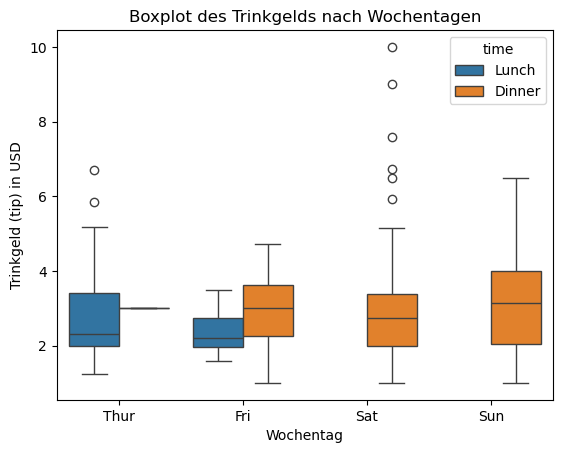

In [9]:
# =============================================================
# Code-Zelle 5: Boxplot Trinkgeld nach Wochentag
# =============================================================

# Reihenfolge der Tage festlegen (Thur, Fri, Sat, Sun)
days_order = ["Thur", "Fri", "Sat", "Sun"]
df["day"] = pd.Categorical(df["day"], categories=days_order, ordered=True)

# Daten in Listenform für Matplotlib Boxplot
data_by_day = [df.loc[df["day"] == day, "tip"] for day in days_order]

# plt.boxplot(data_by_day, labels=days_order)
plt.xlabel("Wochentag")
plt.ylabel("Trinkgeld (tip) in USD")

# Alternativ mit Seaborn:
sns.boxplot(x="day", y="tip", hue="time", data=df, order=days_order)
plt.title("Boxplot des Trinkgelds nach Wochentagen")
plt.show()

### Interpretation:
- Man kann erkennen, ob es an bestimmten Tagen Ausreißer gibt oder der Median höher liegt.
- Oft ist am Wochenende (Sa/So) das Trinkgeld etwas höher.

---

### 3.2.3 Barplot: Durchschnittliches Trinkgeld nach Raucherstatus
Hier schauen wir uns an, ob Raucher oder Nichtraucher im Schnitt mehr Trinkgeld geben.

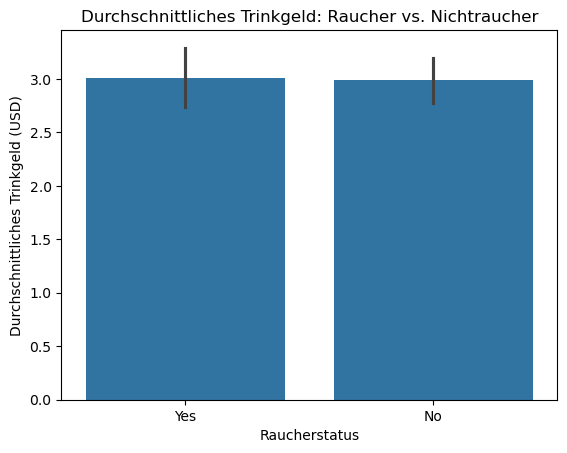

In [11]:
# =============================================================
# Code-Zelle 6: Barplot Raucher vs. Nichtraucher
# =============================================================
mean_tip_by_smoker = df.groupby("smoker", observed=True)["tip"].mean()

# Matplotlib
categories = mean_tip_by_smoker.index.tolist()
means = mean_tip_by_smoker.values.tolist()

# plt.bar(categories, means)
plt.xlabel("Raucherstatus")
plt.ylabel("Durchschnittliches Trinkgeld (USD)")
plt.title("Durchschnittliches Trinkgeld: Raucher vs. Nichtraucher")
# plt.show()

# Alternativ mit Seaborn:
sns.barplot(x="smoker", y="tip", data=df, estimator=np.mean)
# plt.title("Durchschnittliches Trinkgeld: Raucher vs. Nichtraucher")
plt.show()

### Interpretation:
- Liegen die Balken näher beieinander, deutet es darauf hin, dass Raucher- und Nichtrauchergruppen ähnlich viel Trinkgeld geben. 
- Unterschiede können zufällig sein und wären durch weitere statistische Tests genauer zu beleuchten.


## 3.2.3 Visualisierung: Trinkgeld vs. Gesamtrechnung

###  Begründung für diese Darstellung
Um Zusammenhänge zwischen der Höhe des Trinkgelds und der Rechnung nachvollziehen zu können, bietet sich ein Streudiagramm an, in dem wir auf der **x-Achse** die Gesamtrechnung (`total_bill`) und auf der **y-Achse** das Trinkgeld (`tip`) abbilden. Da wir vermuten, dass sowohl der **Wochentag** als auch die **Tageszeit** (Lunch vs. Dinner) und die **Gruppengröße** (Anzahl der Personen) eine Rolle spielen könnten, nutzen wir **Farbe** (`hue`), **Marker-Stil** (`style`) und **Punktgröße** (`size`) als zusätzliche Dimensionen. So gewinnen wir einen mehrdimensionalen Überblick über mögliche Muster.

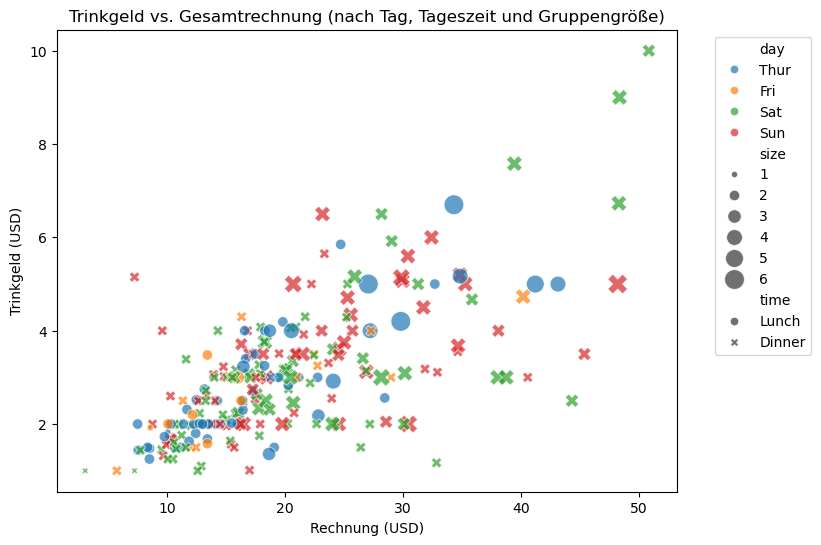

In [14]:
# =============================================================
# Code-Zelle 7: Multidimensionale Visualisierung
# =============================================================


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="total_bill",   # Rechnung
    y="tip",          # Trinkgeld
    hue="day",        # Farbe nach Wochentag
    style="time",     # Marker-Stil nach Tageszeit (Lunch/Dinner)
    size="size",      # Punktgröße nach Personenzahl
    sizes=(20, 200),  # Anpassen des Größenbereichs
    alpha=0.7         # Transparenz für bessere Lesbarkeit
)
plt.title("Trinkgeld vs. Gesamtrechnung (nach Tag, Tageszeit und Gruppengröße)")
plt.xlabel("Rechnung (USD)")
plt.ylabel("Trinkgeld (USD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 3.2.3 Interpretation

- **Positiver Zusammenhang zwischen Rechnung und Trinkgeld:**  
  Es zeigt sich ein deutlicher Trend: Höhere Rechnungen gehen tendenziell mit höherem Trinkgeld einher – dieser Zusammenhang ist konsistent über alle Wochentage hinweg sichtbar. Die Punkte häufen sich entlang einer aufsteigenden Diagonale, was auf eine proportional steigende Trinkgeldbereitschaft schließen lässt.

- **Einfluss der Tageszeit:**  
  Die meisten Datenpunkte gehören zur Kategorie „Dinner“ (x-Marker). Diese erscheinen über das gesamte Spektrum der Rechnungsbeträge hinweg – von kleinen bis sehr hohen Beträgen. Die „Lunch“-Datenpunkte (runder Marker) erscheinen hingegen seltener und sind stärker im Bereich der niedrigeren Rechnungen vertreten. Das deutet darauf hin, dass Dinner-Besuche nicht nur häufiger im Datensatz sind, sondern auch mit höheren Rechnungen (und Trinkgeldern) einhergehen.

- **Gruppengröße beeinflusst nicht zwingend die Trinkgeldhöhe:**  
  Obwohl größere Punkte (größere Gruppen) bei höheren Rechnungen zu finden sind, ist die **Streuung des Trinkgelds auch bei gleicher Gruppengröße** recht hoch. Das deutet darauf hin, dass nicht allein die Personenzahl entscheidend für die Höhe des Trinkgelds ist – weitere Einflussfaktoren wie Servicequalität oder individuelle Großzügigkeit könnten eine Rolle spielen.

- **Wochentagsunterschiede sind sichtbar, aber nicht extrem ausgeprägt:**  
  Die Farbverteilung der Punkte zeigt, dass Gäste an allen Tagen Trinkgeld geben – größere Unterschiede zwischen den Tagen sind **nicht offensichtlich dominant**. Am Wochenende (insb. **Samstag**, grün, und **Sonntag**, rot) treten allerdings häufiger höhere Rechnungsbeträge auf, was vermutlich mit längeren Aufenthalten oder größeren Gruppen zusammenhängt.

### 📌 Gesamtbewertung:

Die Visualisierung verdeutlicht, dass das Trinkgeld stark mit der Rechnungshöhe korreliert, jedoch auch von weiteren Faktoren beeinflusst wird. Während die **Tageszeit** (Lunch vs. Dinner) ein deutlicher Faktor für die Höhe der Rechnung zu sein scheint, ist der Einfluss der **Gruppengröße** und des **Wochentags** weniger eindeutig. 



## 3.3 Korrelationen

Eine **Korrelationsmatrix** zeigt, wie stark die numerischen Variablen linear zusammenhängen.

In [17]:
# =============================================================
# Code-Zelle 8: Korrelationsmatrix
# =============================================================
corr_matrix = df.corr(numeric_only=True)  # neuere pandas-Versionen
corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

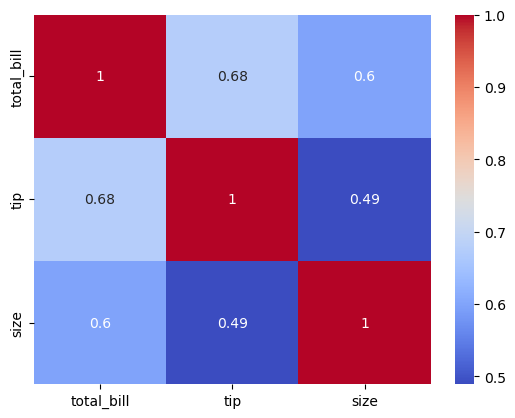

In [18]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

Der Wert zwischen **total_bill** und **tip** ist oft am relevantesten, denn intuitiv steigt das Trinkgeld in absoluten Zahlen mit der Gesamtrechnung. 



# 4. Fazit

## Zusammenfassung der Erkenntnisse
1. **Datenvalidierung**: Der Datensatz ist gut strukturiert und weist keine fehlenden Werte auf.  
2. **Deskriptive Statistik**: Die meisten Trinkgelder liegen zwischen 2 und 3 USD; die Verteilung zeigt eine leichte Schiefe zu höheren Werten.  
3. **Gruppenvergleiche**: Es lassen sich keine signifikanten Unterschiede im Trinkgeldverhalten zwischen Rauchern und Nichtrauchern erkennen.
4. **Multidimensionale Visualisierung**: Die Streuung der Daten nach Wochentag, Tageszeit und Gruppengröße zeigt zusätzliche Muster: Dinner-Besuche gehen häufiger mit höheren Rechnungen einher, größere Gruppen verursachen höhere Rechnungen, jedoch nicht zwangsläufig höheres Trinkgeld. Unterschiede zwischen Wochentagen sind vorhanden, aber nicht stark ausgeprägt.
5. **Korrelation**: Es besteht ein klarer positiver Zusammenhang zwischen `total_bill` und `tip`. Höhere Rechnungen führen tendenziell zu höheren Trinkgeldern.  

## Relevanz & Praktische Implikationen
- Das Verständnis der Zusammenhänge zwischen Rechnung, Trinkgeld, Tageszeit und Gruppengröße liefert wertvolle Hinweise für Gastronomiebetriebe.  
- Servicekräfte, die große Gruppen bedienen oder zur Dinner-Zeit arbeiten, haben tendenziell bessere Chancen auf höheres Trinkgeld – zumindest in absoluten Beträgen.  
- Die Visualisierung kann als Entscheidungshilfe für Personalplanung, Marketingaktionen (z. B. „Lunch Specials“) und Schulungen im Service dienen.

## Limitationen
- Der Datensatz basiert auf Beobachtungen aus einem einzelnen Restaurant; die Ergebnisse sind daher nicht ohne Weiteres generalisierbar.  
- Es fehlen einige potenziell einflussreiche Variablen, wie Servicequalität, Zahlungsart, Trinkgeldkultur der Gäste oder situative Faktoren wie Feiertage.  
- Gruppengröße und Tageszeit zeigen Einfluss, aber deren Wechselwirkungen wurden nicht isoliert modelliert.

## Ausblick
- Weitere Analysen könnten z. B. die Wechselwirkung zwischen Tageszeit und Gruppengröße untersuchen.  
- Die Integration externer Faktoren wie Uhrzeit, Wochentagstyp (Feiertag, Schulferien), Wetter oder Tischlage könnte zu detaillierteren Vorhersagemodellen führen.  
- Ein Regressionsmodell mit Interaktionstermen oder maschinelles Lernen könnte genutzt werden, um Vorhersagen für Trinkgeldbeträge auf Basis mehrerer Merkmale gleichzeitig zu treffen.
